# Capstone Project 3: Predicting Academic Success Across Cohorts

## Fall 2018 versus Fall 2021

Institutions often need to identify students who are likely to achieve strong academic outcomes after their first year. In this capstone, academic success is defined as earning a third-semester GPA of **3.0 or higher**.

You will build and compare four classification models, examine whether performance differs between the Fall 2018 and Fall 2021 cohorts, assess the contribution of survey data, and explore student profiles through unsupervised learning.

## Learning Objectives

By the end of this capstone, you will be able to:

- create a binary academic-success target from third-semester GPA;
- prepare regular and survey-enhanced feature sets;
- train Logistic Regression, Decision Tree, and XGBoost classifiers;
- compare XGBoost with and without survey information;
- evaluate model performance overall and across student cohorts;
- interpret feature importance and performance differences;
- apply K-Means clustering and PCA to explore student profiles; and
- communicate findings in an institutional report.

# Understand

## Step 1: Import Libraries and Set the Data Path

Begin by importing the libraries used for data preparation, modeling, evaluation, and visualization. The project files are stored in one data directory so the remaining code can use clear and consistent file references.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
DATA_DIR = Path('/content/drive/MyDrive/projects2/Applied-Data-Analytics-For-Higher-Education-Course-3/data')

## Step 2: Load the Regular and Survey-Enhanced Data

The regular dataset contains student background and academic information. The survey-enhanced dataset contains the same student records with additional survey-derived components that can be used by the survey model.

In [3]:
train_df = pd.read_csv(DATA_DIR / 'training.csv')
survey_train_df = pd.read_csv(DATA_DIR / 'ML_SURVEY_MASTER_TRAIN.csv')

print('Regular training data:', train_df.shape)
print('Survey-enhanced training data:', survey_train_df.shape)

display(train_df.head())

Regular training data: (19844, 27)
Survey-enhanced training data: (19844, 53)


,SID,COHORT,RACE_ETHNICITY,GENDER,FIRST_GEN_STATUS,HS_GPA,HS_MATH_GPA,HS_ENGL_GPA,COLLEGE,UNITS_ATTEMPTED_1,...,DFW_UNITS_3,GPA_1,GPA_2,GPA_3,SEM_3_STATUS,DFW_RATE_1,DFW_RATE_2,GRADE_POINTS_1,GRADE_POINTS_2,GRADE_POINTS_3
0,UHDOP5522,Fall 2020,Asian,Female,Continuing Generation,3.720,3.2,3.400,Visual & Performing Arts,15.0,...,0.0,4.000000,3.785714,4.0,E,0.0000,0.000000,60.0,53.0,60.0
1,UHE842CU6,Fall 2021,Black or African American,Female,Continuing Generation,3.189,2.6,3.750,Visual & Performing Arts,12.0,...,12.0,3.000000,2.500000,1.5,E,0.0000,0.000000,36.0,30.0,18.0
2,UHJFT1JAB,Fall 2018,Asian,Female,Continuing Generation,3.625,3.4,3.500,Visual & Performing Arts,15.0,...,0.0,3.800000,3.600000,3.6,E,0.0000,0.000000,57.0,54.0,54.0
3,UHKF05TAF,Fall 2018,Hispanic,Female,First Generation,3.606,3.0,3.375,Letters & Humanities,16.0,...,3.0,1.562500,1.000000,2.5,E,0.5625,0.666667,25.0,9.0,30.0
4,UHKKQ8UY5,Fall 2021,Hispanic,Male,Continuing Generation,3.536,2.5,2.625,Letters & Humanities,13.0,...,0.0,3.538462,3.769231,3.4,E,0.0000,0.000000,46.0,49.0,51.0


## Step 3: Review the Available Variables

Review the data structure before modeling. The third-semester GPA will be used only to create the target, while first-year academic variables and student background characteristics will serve as predictors.

In [4]:
print('Regular dataset columns:')
print(train_df.columns.tolist())

print()
print('Cohort distribution:')
display(train_df['COHORT'].value_counts().sort_index().to_frame('Students'))

print()
print('Third-semester GPA summary:')
display(train_df['GPA_3'].describe().to_frame().T)

Regular dataset columns:
['SID', 'COHORT', 'RACE_ETHNICITY', 'GENDER', 'FIRST_GEN_STATUS', 'HS_GPA', 'HS_MATH_GPA', 'HS_ENGL_GPA', 'COLLEGE', 'UNITS_ATTEMPTED_1', 'UNITS_ATTEMPTED_2', 'UNITS_ATTEMPTED_3', 'UNITS_COMPLETED_1', 'UNITS_COMPLETED_2', 'UNITS_COMPLETED_3', 'DFW_UNITS_1', 'DFW_UNITS_2', 'DFW_UNITS_3', 'GPA_1', 'GPA_2', 'GPA_3', 'SEM_3_STATUS', 'DFW_RATE_1', 'DFW_RATE_2', 'GRADE_POINTS_1', 'GRADE_POINTS_2', 'GRADE_POINTS_3']

Cohort distribution:


,Students
COHORT,
Fall 2018,4925
Fall 2019,5162
Fall 2020,4901
Fall 2021,4856



Third-semester GPA summary:


,count,mean,std,min,25%,50%,75%,max
GPA_3,19844.0,3.166007,0.753915,0.0,2.846154,3.333333,3.714286,4.0


## Step 4: Select the Fall 2018 and Fall 2021 Cohorts

This project compares two entering cohorts while holding the prediction task constant. Restricting the analysis to Fall 2018 and Fall 2021 makes the cohort comparison central to the modeling and evaluation process.

In [5]:
selected_cohorts = ['Fall 2018', 'Fall 2021']
cohort_mask = train_df['COHORT'].isin(selected_cohorts)

cohort_df = train_df.loc[cohort_mask].copy()
cohort_survey_df = survey_train_df.loc[cohort_mask].copy()

print('Selected cohort data:', cohort_df.shape)
display(cohort_df['COHORT'].value_counts().sort_index().to_frame('Students'))

Selected cohort data: (9781, 27)


,Students
COHORT,
Fall 2018,4925
Fall 2021,4856


# Prepare

## Step 5: Create the Academic Success Target

Academic success is defined as earning a third-semester GPA of at least 3.0. The positive class represents students who reached this benchmark, while the negative class represents students whose GPA was below 3.0.

In [6]:
cohort_df['ACADEMIC_SUCCESS'] = (cohort_df['GPA_3'] >= 3.0).astype(int)

y = cohort_df['ACADEMIC_SUCCESS']

success_summary = (
    cohort_df.groupby('COHORT')['ACADEMIC_SUCCESS']
    .agg(Students='size', Success_Rate='mean')
)
success_summary['Success_Rate'] = success_summary['Success_Rate'].round(3)
display(success_summary)

,Students,Success_Rate
COHORT,,
Fall 2018,4925,0.621
Fall 2021,4856,0.706


## Step 6: Define the Regular Feature Set

The regular models use information available by the end of the first academic year. Third-semester variables are excluded because they occur at or after the outcome being predicted and would create target leakage.

In [7]:
numeric_features = [
    'HS_GPA', 'HS_MATH_GPA', 'HS_ENGL_GPA',
    'UNITS_ATTEMPTED_1', 'UNITS_ATTEMPTED_2',
    'UNITS_COMPLETED_1', 'UNITS_COMPLETED_2',
    'DFW_UNITS_1', 'DFW_UNITS_2',
    'GPA_1', 'GPA_2',
    'DFW_RATE_1', 'DFW_RATE_2',
    'GRADE_POINTS_1', 'GRADE_POINTS_2'
]

categorical_features = [
    'RACE_ETHNICITY', 'GENDER', 'FIRST_GEN_STATUS', 'COLLEGE'
]

regular_features = numeric_features + categorical_features
X_regular = cohort_df[regular_features].copy()

print('Regular feature matrix:', X_regular.shape)

Regular feature matrix: (9781, 19)


## Step 7: Define the Survey-Enhanced Feature Set

The survey-enhanced model uses the prepared numeric variables from the survey master dataset. These include first-year academic measures, encoded student characteristics, and text-derived survey components.

In [8]:
survey_features = [
    column for column in cohort_survey_df.columns
    if column != 'SEM_3_STATUS'
]

X_survey = cohort_survey_df[survey_features].copy()

print('Survey-enhanced feature matrix:', X_survey.shape)
print('Survey-derived components:', len([c for c in survey_features if c.startswith('TEXT_PC')]))

Survey-enhanced feature matrix: (9781, 52)
Survey-derived components: 33


## Step 8: Create the Development and Validation Sets

The same row indices are used for the regular and survey-enhanced feature sets. Stratification preserves both the cohort distribution and the academic-success distribution in the development and validation samples.

In [9]:
stratify_groups = cohort_df['COHORT'].astype(str) + '_' + y.astype(str)

train_index, validation_index = train_test_split(
    cohort_df.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=stratify_groups
)

X_train = X_regular.loc[train_index]
X_validation = X_regular.loc[validation_index]
y_train = y.loc[train_index]
y_validation = y.loc[validation_index]

X_survey_train = X_survey.loc[train_index]
X_survey_validation = X_survey.loc[validation_index]

cohort_validation = cohort_df.loc[validation_index, 'COHORT']

print('Development rows:', len(train_index))
print('Validation rows:', len(validation_index))
display(pd.crosstab(cohort_validation, y_validation, margins=True))

Development rows: 7335
Validation rows: 2446


ACADEMIC_SUCCESS,0,1,All
COHORT,,,
Fall 2018,467,765,1232
Fall 2021,357,857,1214
All,824,1622,2446


## Step 9: Build the Preprocessing Pipelines

Numeric variables are imputed and standardized for models that benefit from scaling. Categorical variables are imputed and one-hot encoded. Survey features are numeric, so they are imputed and standardized in a separate pipeline.

In [10]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

regular_preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

survey_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Analyze

## Step 10: Train Logistic Regression

Logistic Regression provides an interpretable baseline for binary classification. It estimates the probability that a student will achieve the academic-success benchmark.

In [11]:
logistic_model = Pipeline([
    ('preprocessor', regular_preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

logistic_model.fit(X_train, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


## Step 11: Train the Decision Tree

A Decision Tree captures nonlinear relationships and interactions through a sequence of decision rules. Limiting tree depth helps maintain interpretability and reduce overfitting.

In [12]:
decision_tree_model = Pipeline([
    ('preprocessor', regular_preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=25,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

decision_tree_model.fit(X_train, y_train)
print('Decision Tree trained.')

Decision Tree trained.


## Step 12: Train XGBoost Without Survey Data

XGBoost combines many shallow trees to capture complex patterns. This model uses the same regular feature set as Logistic Regression and the Decision Tree.

In [13]:
xgb_model = Pipeline([
    ('preprocessor', regular_preprocessor),
    ('model', XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ))
])

xgb_model.fit(X_train, y_train)
print('XGBoost trained without survey data.')

XGBoost trained without survey data.


## Step 13: Train XGBoost With Survey Data

The survey-enhanced XGBoost model adds survey-derived components to the academic and demographic information. Comparing the two XGBoost models will show whether survey information improves prediction.

In [14]:
xgb_survey_model = Pipeline([
    ('preprocessor', survey_preprocessor),
    ('model', XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ))
])

xgb_survey_model.fit(X_survey_train, y_train)
print('XGBoost trained with survey data.')

XGBoost trained with survey data.


## Step 14: Compare Overall Model Performance

Evaluate each model on the same validation students. Accuracy summarizes overall correctness, while precision, recall, F1, and ROC-AUC provide a broader view of classification quality.

In [15]:
models = {
    'Logistic Regression': (logistic_model, X_validation),
    'Decision Tree': (decision_tree_model, X_validation),
    'XGBoost': (xgb_model, X_validation),
    'XGBoost + Survey': (xgb_survey_model, X_survey_validation)
}

predictions = {}
probabilities = {}
results = []

for model_name, (model, features) in models.items():
    y_pred = model.predict(features)
    y_prob = model.predict_proba(features)[:, 1]

    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_validation, y_pred),
        'Precision': precision_score(y_validation, y_pred, zero_division=0),
        'Recall': recall_score(y_validation, y_pred, zero_division=0),
        'F1': f1_score(y_validation, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_validation, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model').round(3)
display(results_df.sort_values('ROC_AUC', ascending=False))

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
XGBoost,0.764,0.815,0.833,0.824,0.833
XGBoost + Survey,0.757,0.812,0.824,0.818,0.827
Decision Tree,0.737,0.850,0.733,0.787,0.807
Logistic Regression,0.711,0.843,0.693,0.761,0.785


## Step 15: Visualize Model Performance

A visual comparison makes it easier to identify performance tradeoffs. Focus on whether one model remains strong across several metrics rather than relying on accuracy alone.

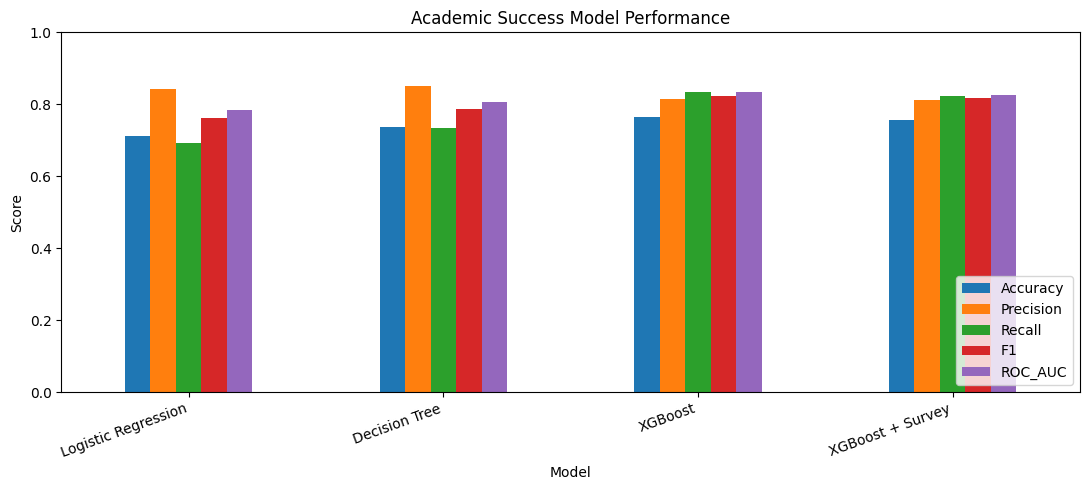

In [16]:
results_df.plot(kind='bar', figsize=(11, 5))
plt.title('Academic Success Model Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 16: Compare ROC Curves and Confusion Matrices

ROC curves compare the ranking ability of the models across classification thresholds. Confusion matrices show the types of correct and incorrect predictions at the default threshold.

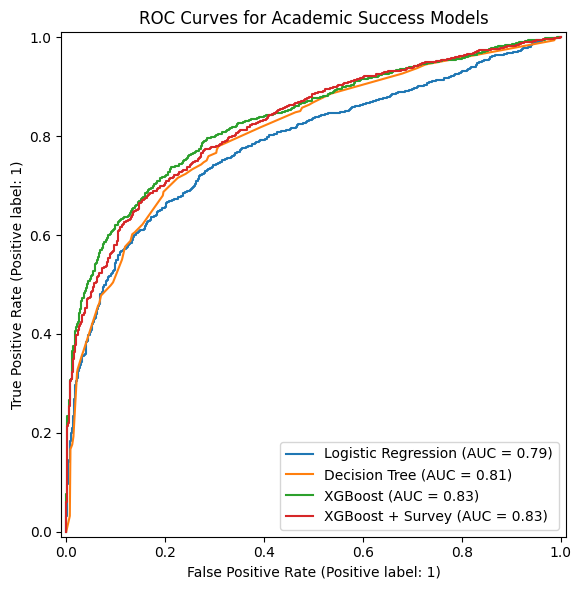

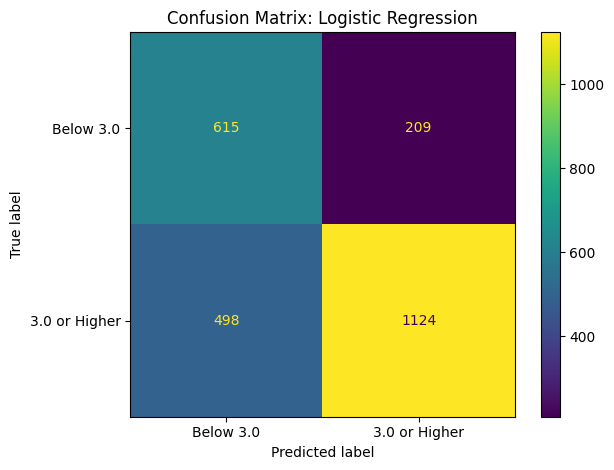

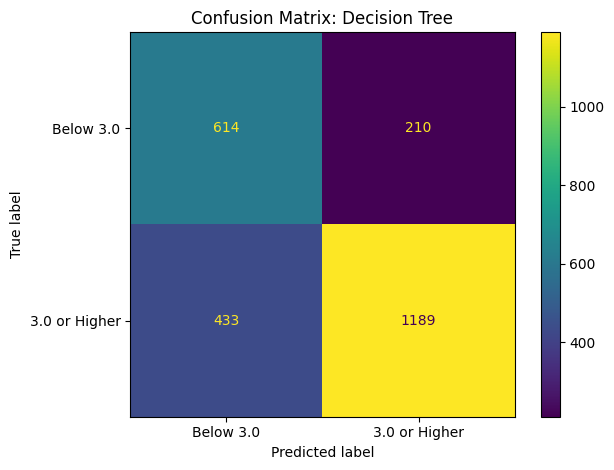

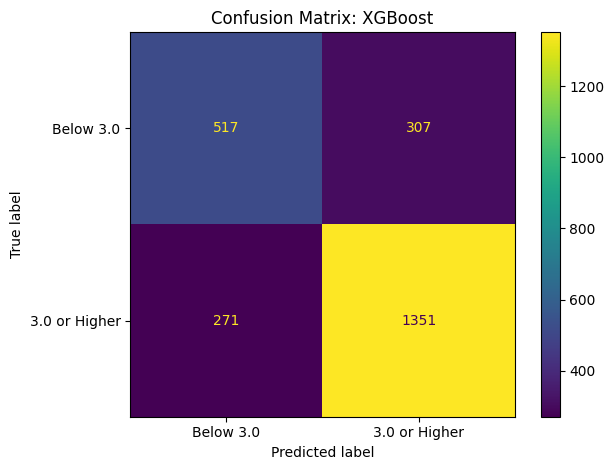

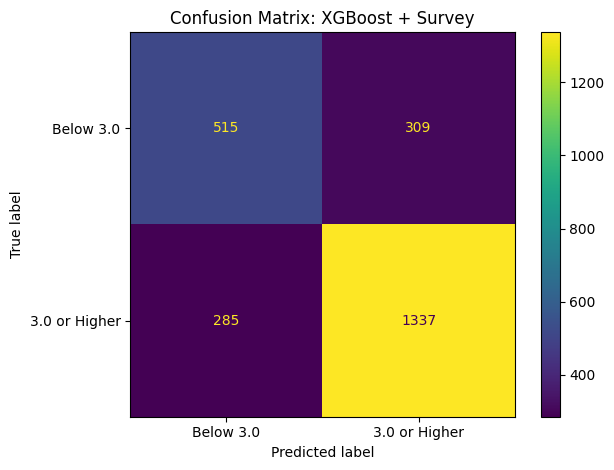

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for model_name, y_prob in probabilities.items():
    RocCurveDisplay.from_predictions(
        y_validation,
        y_prob,
        name=model_name,
        ax=ax
    )
plt.title('ROC Curves for Academic Success Models')
plt.tight_layout()
plt.show()

for model_name, y_pred in predictions.items():
    ConfusionMatrixDisplay.from_predictions(
        y_validation,
        y_pred,
        display_labels=['Below 3.0', '3.0 or Higher']
    )
    plt.title(f'Confusion Matrix: {model_name}')
    plt.tight_layout()
    plt.show()

## Step 17: Evaluate Performance Across Cohorts

Overall metrics can hide differences between student populations. Evaluate each model separately for Fall 2018 and Fall 2021 to determine whether predictive quality remains consistent across cohorts.

,Model,Cohort,Students,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,Fall 2018,1232,0.695,0.835,0.634,0.721,0.779
1,Logistic Regression,Fall 2021,1214,0.727,0.850,0.746,0.794,0.787
2,Decision Tree,Fall 2018,1232,0.722,0.837,0.686,0.754,0.802
3,Decision Tree,Fall 2021,1214,0.752,0.860,0.775,0.815,0.806
4,XGBoost,Fall 2018,1232,0.752,0.807,0.791,0.799,0.818
5,XGBoost,Fall 2021,1214,0.775,0.822,0.870,0.845,0.843
6,XGBoost + Survey,Fall 2018,1232,0.746,0.801,0.787,0.794,0.820
7,XGBoost + Survey,Fall 2021,1214,0.769,0.822,0.858,0.840,0.828


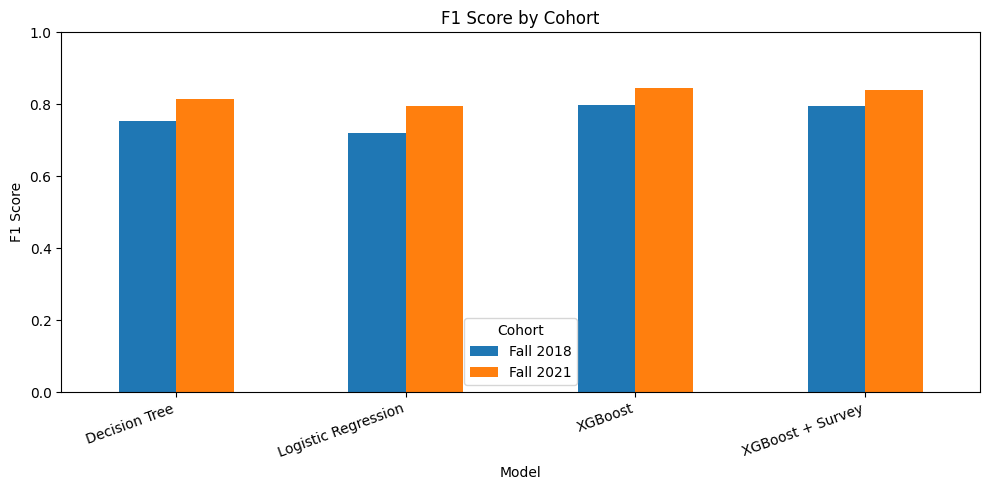

In [18]:
cohort_results = []

for model_name in models:
    for cohort_name in selected_cohorts:
        mask = cohort_validation == cohort_name
        y_true_group = y_validation.loc[mask]
        y_pred_group = pd.Series(predictions[model_name], index=y_validation.index).loc[mask]
        y_prob_group = pd.Series(probabilities[model_name], index=y_validation.index).loc[mask]

        cohort_results.append({
            'Model': model_name,
            'Cohort': cohort_name,
            'Students': mask.sum(),
            'Accuracy': accuracy_score(y_true_group, y_pred_group),
            'Precision': precision_score(y_true_group, y_pred_group, zero_division=0),
            'Recall': recall_score(y_true_group, y_pred_group, zero_division=0),
            'F1': f1_score(y_true_group, y_pred_group, zero_division=0),
            'ROC_AUC': roc_auc_score(y_true_group, y_prob_group)
        })

cohort_results_df = pd.DataFrame(cohort_results).round(3)
display(cohort_results_df)

f1_comparison = cohort_results_df.pivot(index='Model', columns='Cohort', values='F1')
f1_comparison.plot(kind='bar', figsize=(10, 5))
plt.title('F1 Score by Cohort')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Step 18: Examine Feature Importance

Feature importance helps explain which regular variables contribute most to the XGBoost predictions. Importance indicates predictive contribution within the model, not a causal relationship.

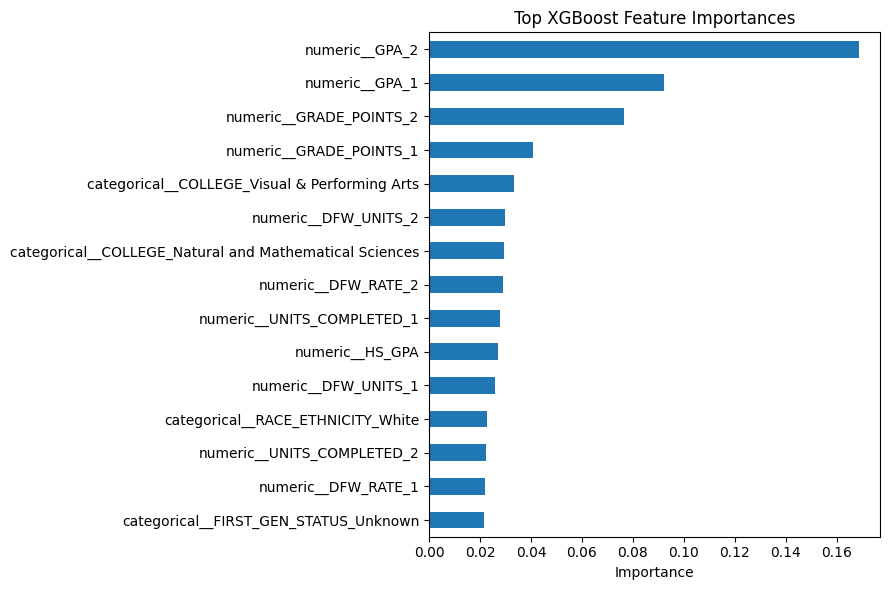

,Importance
numeric__GPA_2,0.168548
numeric__GPA_1,0.092284
numeric__GRADE_POINTS_2,0.076488
numeric__GRADE_POINTS_1,0.040632
categorical__COLLEGE_Visual & Performing Arts,0.033261
numeric__DFW_UNITS_2,0.029859
categorical__COLLEGE_Natural and Mathematical Sciences,0.029498
numeric__DFW_RATE_2,0.028937
numeric__UNITS_COMPLETED_1,0.027861
numeric__HS_GPA,0.026990


In [19]:
feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()
feature_importance = pd.Series(
    xgb_model.named_steps['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

feature_importance.sort_values().plot(kind='barh', figsize=(9, 6))
plt.title('Top XGBoost Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

display(feature_importance.to_frame('Importance'))

## Step 19: Assess the Contribution of Survey Data

Compare the two XGBoost models directly. The difference in performance shows whether adding survey-derived information improved prediction on the validation sample.

In [20]:
survey_impact = results_df.loc[['XGBoost', 'XGBoost + Survey']].copy()
survey_impact.loc['Difference: Survey - Regular'] = (
    survey_impact.loc['XGBoost + Survey'] - survey_impact.loc['XGBoost']
)

display(survey_impact.round(3))

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
XGBoost,0.764,0.815,0.833,0.824,0.833
XGBoost + Survey,0.757,0.812,0.824,0.818,0.827
Difference: Survey - Regular,-0.007,-0.003,-0.009,-0.006,-0.006


# Unsupervised Learning

## Step 20: Create and Visualize Student Survey Profiles

Supervised learning predicts a known outcome, while clustering looks for natural groupings without using the academic-success label. K-Means will create three student profiles from the survey components, and PCA will project those profiles into two dimensions for visualization.

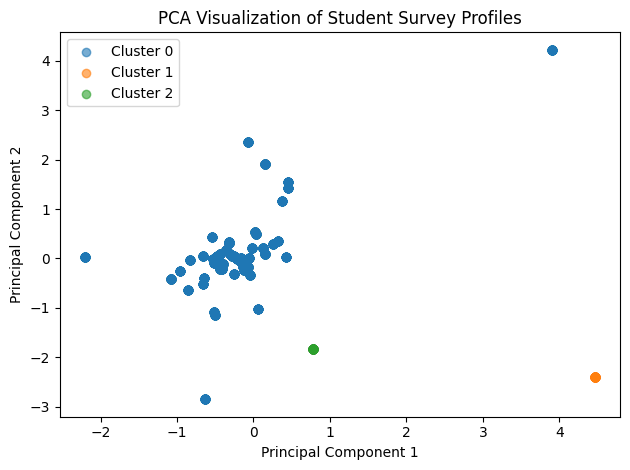

,Students,Academic_Success_Rate
Cluster,,
0,2275,0.659
1,83,0.771
2,88,0.670


Cohort,Fall 2018,Fall 2021
Cluster,,
0,0.506,0.494
1,0.458,0.542
2,0.489,0.511


In [21]:
text_features = [column for column in X_survey_validation.columns if column.startswith('TEXT_PC')]

cluster_data = X_survey_validation[text_features].copy()
cluster_data = SimpleImputer(strategy='median').fit_transform(cluster_data)
cluster_data_scaled = StandardScaler().fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_data_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coordinates = pca.fit_transform(cluster_data_scaled)

cluster_plot_df = pd.DataFrame({
    'PC1': pca_coordinates[:, 0],
    'PC2': pca_coordinates[:, 1],
    'Cluster': cluster_labels,
    'Cohort': cohort_validation.values,
    'Academic_Success': y_validation.values
}, index=validation_index)

for cluster_number in sorted(cluster_plot_df['Cluster'].unique()):
    cluster_points = cluster_plot_df[cluster_plot_df['Cluster'] == cluster_number]
    plt.scatter(
        cluster_points['PC1'],
        cluster_points['PC2'],
        label=f'Cluster {cluster_number}',
        alpha=0.6
    )

plt.title('PCA Visualization of Student Survey Profiles')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

cluster_profile = cluster_plot_df.groupby('Cluster').agg(
    Students=('Academic_Success', 'size'),
    Academic_Success_Rate=('Academic_Success', 'mean')
).round(3)

cohort_mix = pd.crosstab(
    cluster_plot_df['Cluster'],
    cluster_plot_df['Cohort'],
    normalize='index'
).round(3)

display(cluster_profile)
display(cohort_mix)

### Reflection Questions: Unsupervised Learning

1. Which cluster has the highest academic-success rate?
2. Are Fall 2018 and Fall 2021 students distributed differently across the clusters?
3. What additional variables would help describe the student profiles represented by each cluster?
4. How could clustering complement—but not replace—the supervised prediction models?
5. What ethical considerations should guide the use of student profiles in institutional decision-making?

# Deploy

## Step 21: Select a Model for Institutional Use

Model selection should consider overall discrimination, F1 score, cohort consistency, interpretability, and the operational value of survey information. The highest score on one metric does not automatically make a model the best institutional choice.

In [22]:
recommended_model = results_df.sort_values(
    by=['ROC_AUC', 'F1'],
    ascending=False
).index[0]

print('Recommended model based on validation ROC-AUC and F1:')
print(recommended_model)

print()
print('Overall performance:')
display(results_df.loc[[recommended_model]])

print()
print('Cohort performance:')
display(cohort_results_df[cohort_results_df['Model'] == recommended_model])

Recommended model based on validation ROC-AUC and F1:
XGBoost

Overall performance:


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
XGBoost,0.764,0.815,0.833,0.824,0.833



Cohort performance:


,Model,Cohort,Students,Accuracy,Precision,Recall,F1,ROC_AUC
4,XGBoost,Fall 2018,1232,0.752,0.807,0.791,0.799,0.818
5,XGBoost,Fall 2021,1214,0.775,0.822,0.870,0.845,0.843


## Step 22: Produce a Comprehensive Report on Your Findings

Prepare a concise institutional report that explains the modeling approach, findings, limitations, and recommended use. Support each conclusion with evidence from the notebook rather than relying on a single metric.

### 1. Problem and Data

- Explain how academic success was defined.
- Describe the Fall 2018 and Fall 2021 cohorts.
- Identify the regular and survey-enhanced information used for prediction.

### 2. Overall Model Performance

- Compare Logistic Regression, Decision Tree, XGBoost, and XGBoost with survey data.
- Identify the strongest model and the metrics supporting that conclusion.
- Discuss important tradeoffs among accuracy, recall, F1, and ROC-AUC.

### 3. Cohort-Level Performance

- Compare model performance for Fall 2018 and Fall 2021.
- Identify meaningful differences in recall, F1, or ROC-AUC.
- Discuss why cohort-level evaluation matters before institutional deployment.

### 4. Model Interpretation and Survey Contribution

- Summarize the most influential regular predictors.
- Explain whether survey information improved performance.
- Distinguish predictive importance from causal explanation.

### 5. Unsupervised Learning Insights

- Describe the three student profiles created through K-Means.
- Compare academic-success rates and cohort representation across clusters.
- Explain how clustering could support exploratory institutional analysis.

### 6. Recommendation

- Recommend one model for institutional consideration.
- Describe how predictions could support academic advising or student-success programs.
- Identify limitations, ethical risks, and monitoring practices that should accompany implementation.

## Conclusion

This capstone combines supervised and unsupervised learning to study academic success across student cohorts. A responsible institutional recommendation should balance predictive performance, consistency across cohorts, interpretability, privacy, and the potential consequences of acting on model outputs.